In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import math
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import seaborn as sns

In [21]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)

## Loading data tables and joining them

In [18]:
USER = "kamil"
HOST = "localhost"
PORT = "5432"
DB = "chembl_36"

In [19]:
engine = create_engine(f"postgresql://{USER}@{HOST}:{PORT}/{DB}")
engine.connect()

In [20]:
ROW_LIMIT=5000

Should we keep rows with standard_relation different than `=`?

In [45]:
query = f"""
SELECT 
    a.activity_id,
    a.assay_id,
    a.record_id,
    a.molregno,
    a.standard_value as ic50,
    a.standard_units,
    cs.canonical_smiles as smiles,
    ass.assay_type,
    ass.confidence_score,
    ass.tid as target_id, 
    md.molecule_type,
    md.chirality, 
    md.structure_type,
    cp.*
FROM activities a
JOIN assays ass ON a.assay_id = ass.assay_id 
JOIN molecule_dictionary md ON a.molregno = md.molregno
JOIN compound_structures cs ON a.molregno = cs.molregno
LEFT JOIN compound_properties cp ON a.molregno = cp.molregno
WHERE 
    standard_type = 'IC50' 
AND standard_relation = '=' \
AND cs.canonical_smiles IS NOT NULL 
AND a.standard_value IS NOT NULL
AND a.standard_units IS NOT NULL
LIMIT {ROW_LIMIT}
"""
df = pd.read_sql(query, engine)
df.head()

,activity_id,assay_id,record_id,molregno,ic50,standard_units,smiles,assay_type,confidence_score,target_id,molecule_type,chirality,structure_type,molregno,mw_freebase,alogp,hba,hbd,psa,rtb,ro3_pass,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,full_molformula,np_likeness_score
0,568109,7,338777,286631,0.8,nM,CCC(CC)n1c(C)cc2c3c(N)nc(N)nc3ccc21,F,1,80001,Small molecule,-1,MOL,286631,283.38,3.42,5.0,2.0,82.75,3.0,N,0.0,283.38,3.0,21.0,0.77,C16H21N5,-0.98
1,579288,7,338768,49931,8.8,nM,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H](CC...,F,1,80001,Small molecule,1,MOL,49931,454.45,0.27,10.0,5.0,210.54,9.0,N,0.0,454.45,3.0,33.0,0.29,C20H22N8O5,-0.53
2,865575,9,76002,69954,118000.0,nM,COC(=O)C1C(C(=O)O)[C@@H]2CC[C@H]1O2,F,1,80001,Small molecule,-1,MOL,69954,200.19,0.04,4.0,1.0,72.83,2.0,N,0.0,200.19,0.0,14.0,0.64,C9H12O5,0.81
3,865583,9,75997,3133,43000.0,nM,O=C1OC(=O)C2C3CCC(O3)C12,F,1,80001,Small molecule,-1,MOL,3133,168.15,-0.14,4.0,0.0,52.60,0.0,N,0.0,168.15,0.0,12.0,0.37,C8H8O4,1.09
4,869546,9,75995,69711,450000.0,nM,CCCOC(=O)C1C(C(=O)O)[C@@H]2CC[C@H]1O2,F,1,80001,Small molecule,-1,MOL,69711,228.24,0.82,4.0,1.0,72.83,4.0,N,0.0,228.24,0.0,16.0,0.72,C11H16O5,0.34


## Missing values and data types

In [46]:
df.isna().sum()

activity_id            0
assay_id               0
record_id              0
molregno               0
ic50                   0
standard_units         0
smiles                 0
assay_type             0
confidence_score       0
target_id              0
molecule_type          0
chirality              0
structure_type         0
molregno               0
mw_freebase            0
alogp                 97
hba                   97
hbd                   97
psa                   97
rtb                   97
ro3_pass              97
num_ro5_violations    97
full_mwt               0
aromatic_rings        97
heavy_atoms           97
qed_weighted          97
full_molformula        0
np_likeness_score     97
dtype: int64

In [47]:
df.dtypes

activity_id             int64
assay_id                int64
record_id               int64
molregno                int64
ic50                  float64
standard_units         object
smiles                 object
assay_type             object
confidence_score        int64
target_id               int64
molecule_type          object
chirality               int64
structure_type         object
molregno                int64
mw_freebase           float64
alogp                 float64
hba                   float64
hbd                   float64
psa                   float64
rtb                   float64
ro3_pass               object
num_ro5_violations    float64
full_mwt              float64
aromatic_rings        float64
heavy_atoms           float64
qed_weighted          float64
full_molformula        object
np_likeness_score     float64
dtype: object

## Duplicates

This section raises a question: *How do we define a duplicate value and how should we handle them?*

In [48]:
dup1 = df.duplicated(subset=["molregno", "assay_id"], keep=False)
dup1_count = dup1.sum()
dup1_count

np.int64(204)

In [49]:
dup2 = df.duplicated(subset=["molregno", "target_id"], keep=False)
dup2_count = dup2.sum()
dup2_count

np.int64(1100)

## IC50


In [50]:
df["standard_units"].unique()

array(['nM', 'ug.mL-1', 'ppm g dm**-3'], dtype=object)

### Unification of units

In [52]:
def convert_to_nM(row):
    value = row["ic50"]
    unit = row["standard_units"]
    mw = row["full_mwt"]  
    if unit == "nM":
        return value
    
    if unit in ["ug.mL-1", "ppm g dm**-3"] and (mw is None or mw == 0 or np.isnan(mw)):
        return np.nan

    if unit == "ug.mL-1":
        return value * (1e6 / mw)
    
    if unit == "ppm g dm**-3":
        return value * (1e6 / mw)
    return np.nan

df["ic50"] = df.apply(convert_to_nM, axis=1)
df.loc[df["ic50"].notna(), "standard_units"] = "nM"
df = df.dropna(subset=["ic50"])

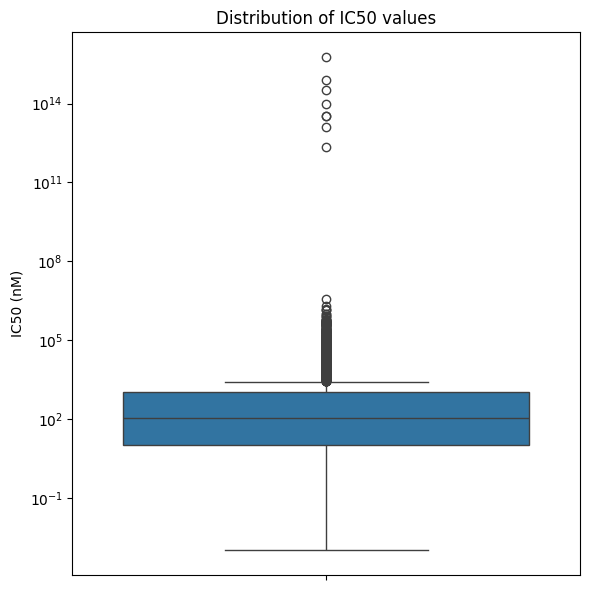

In [55]:
plt.figure(figsize=(6,6))
sns.boxplot(y=df["ic50"])

plt.yscale("log")
plt.ylabel("IC50 (nM)")
plt.title("Distribution of IC50 values")
plt.tight_layout()
plt.show()

In [70]:
df['ic50'].describe()

count    5.000000e+03
mean     1.438697e+12
std      8.419329e+13
min      1.000000e-03
25%      1.000000e+01
50%      1.140000e+02
75%      1.071520e+03
max      5.888437e+15
Name: ic50, dtype: float64

### Calculation of pIC50

In [56]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [57]:
df["pic50"] = df.apply(lambda x: convert_ic50_to_pic50(x.ic50), axis=1)

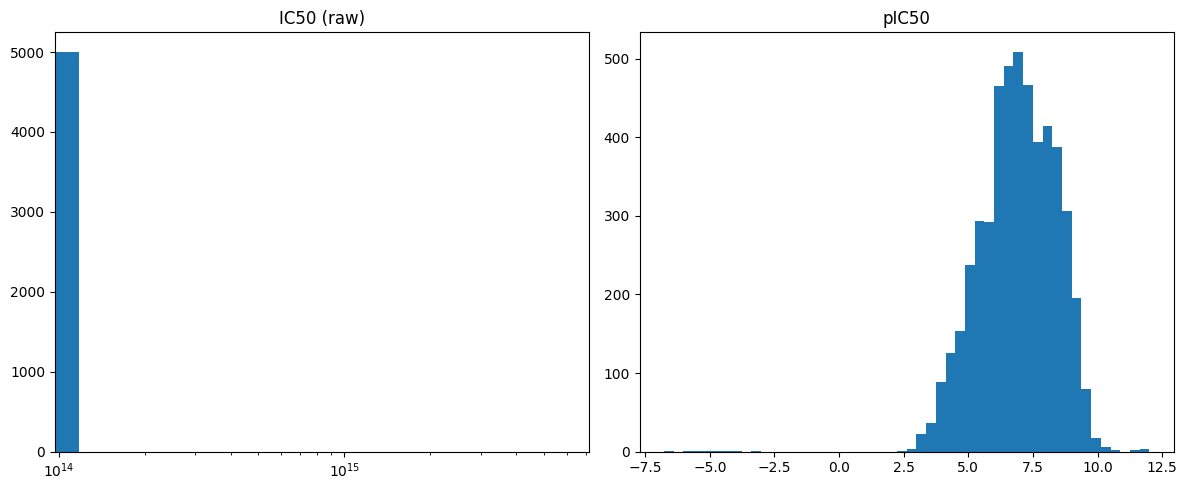

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['ic50'], bins=50)
axes[0].set_title('IC50 (raw)')
axes[0].set_xscale('log')

axes[1].hist(df['pic50'], bins=50)
axes[1].set_title('pIC50')

plt.tight_layout()
plt.show()

## Impact of the assay type on IC50

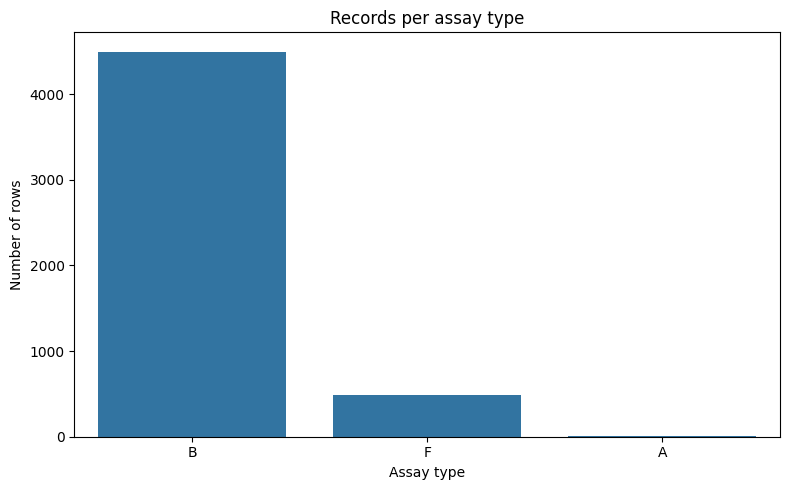

In [61]:
assay_counts = df["assay_type"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=assay_counts.index, y=assay_counts.values)

plt.xlabel("Assay type")
plt.ylabel("Number of rows")
plt.title("Records per assay type")
plt.tight_layout()

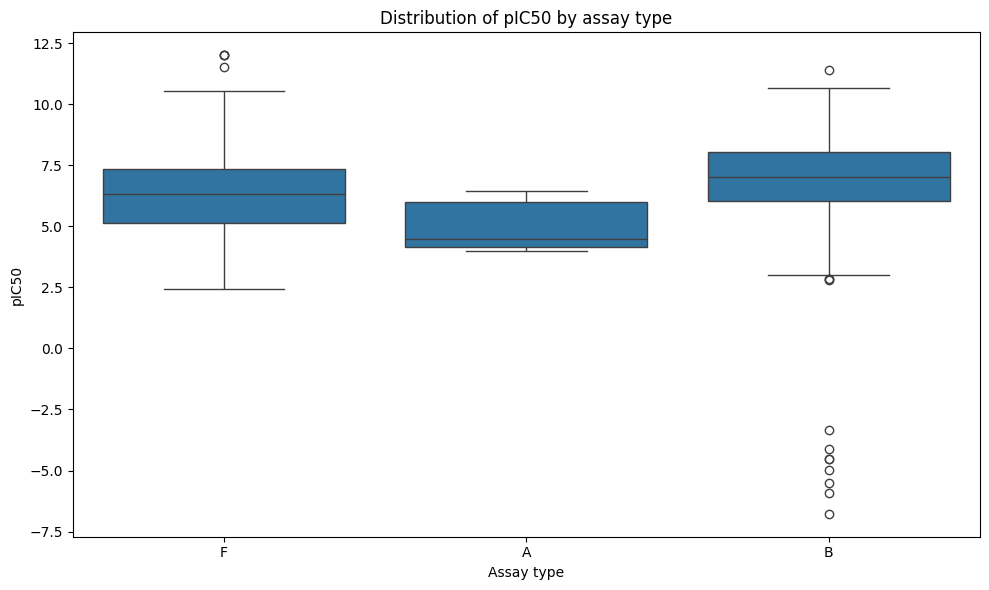

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="assay_type", y="pic50")

plt.xlabel("Assay type")
plt.ylabel("pIC50")
plt.title("Distribution of pIC50 by assay type")
plt.tight_layout()
plt.show()

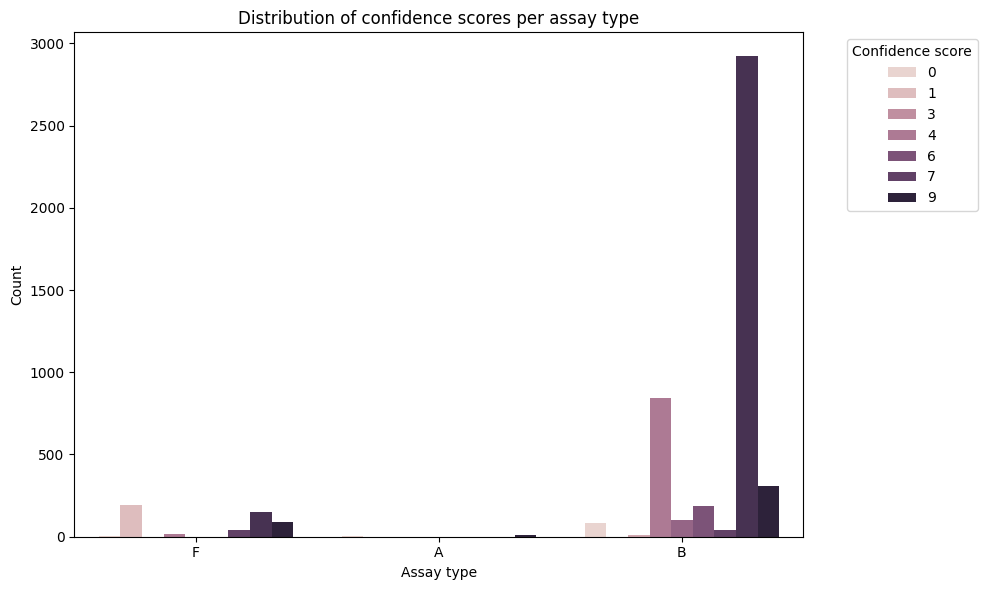

In [64]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="assay_type", hue="confidence_score")

plt.xlabel("Assay type")
plt.ylabel("Count")
plt.title("Distribution of confidence scores per assay type")
plt.legend(title="Confidence score", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

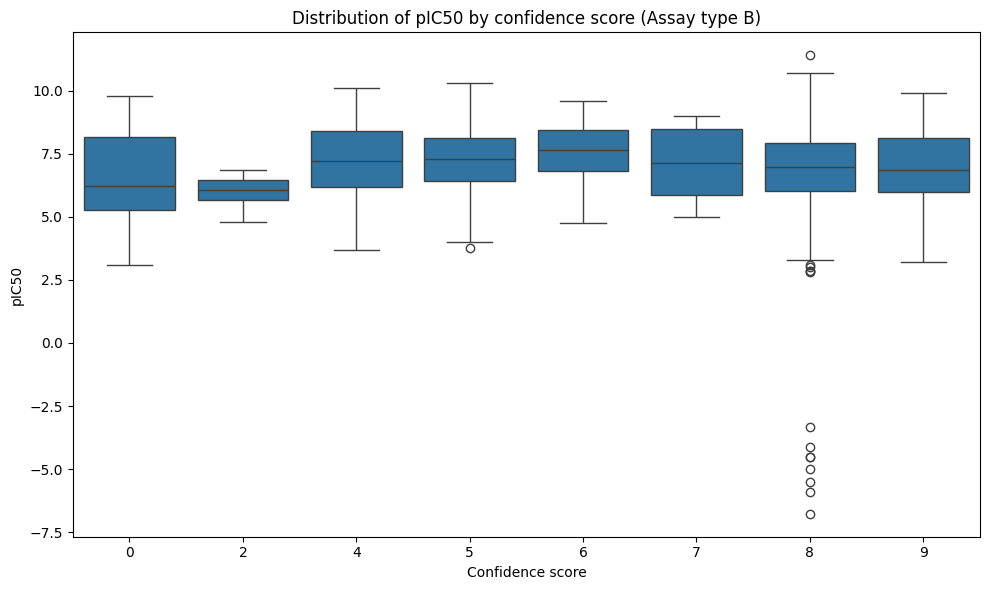

In [ ]:
df_B = df[df["assay_type"] == "B"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_B, x="confidence_score", y="pic50")

plt.xlabel("Confidence score")
plt.ylabel("pIC50")
plt.title("Distribution of pIC50 by confidence score (Assay type B)")
plt.tight_layout()
plt.show()

## Chemical properties

In [77]:
properites = ["pic50", "mw_freebase", "alogp", "hba", "hbd", "psa", "rtb", 
    "full_mwt", "qed_weighted", "np_likeness_score", "aromatic_rings"]

In [82]:
df_sub.isna().sum()

activity_id            0
assay_id               0
record_id              0
molregno               0
ic50                   0
standard_units         0
smiles                 0
assay_type             0
confidence_score       0
target_id              0
molecule_type          0
chirality              0
structure_type         0
molregno               0
mw_freebase            0
alogp                 43
hba                   43
hbd                   43
psa                   43
rtb                   43
ro3_pass              43
num_ro5_violations    43
full_mwt               0
aromatic_rings        43
heavy_atoms           43
qed_weighted          43
full_molformula        0
np_likeness_score     43
pic50                  0
dtype: int64

In [87]:
df_properties = df[cols].copy()
df_properites.dtypes

pic50                float64
mw_freebase          float64
alogp                float64
hba                  float64
hbd                  float64
psa                  float64
rtb                  float64
full_mwt             float64
qed_weighted         float64
np_likeness_score    float64
aromatic_rings       float64
dtype: object

In [88]:
df_properites.describe()

,pic50,mw_freebase,alogp,hba,hbd,psa,rtb,full_mwt,qed_weighted,np_likeness_score,aromatic_rings
count,5000.000000,5000.000000,4903.000000,4903.000000,4903.000000,4903.000000,4903.000000,5000.000000,4903.000000,4903.000000,4903.000000
mean,6.894147,383.240994,3.499600,4.428513,1.062207,53.310267,5.309810,390.754538,0.608652,-0.826153,2.505201
std,1.496464,137.454652,1.374389,1.627656,1.155762,28.648688,3.024664,141.288636,0.181821,0.792195,1.084140
min,-6.770000,154.160000,-4.310000,0.000000,0.000000,3.240000,0.000000,154.160000,0.030000,-2.660000,0.000000
25%,5.970000,302.110000,2.685000,3.000000,0.000000,31.720000,3.000000,306.340000,0.470000,-1.410000,2.000000
50%,6.943095,375.870000,3.550000,4.000000,1.000000,51.210000,5.000000,383.810000,0.630000,-0.980000,2.000000
75%,8.000000,432.590000,4.330000,5.000000,2.000000,67.870000,7.000000,440.580000,0.760000,-0.350000,3.000000
max,12.000000,1385.500000,18.090000,13.000000,7.000000,243.320000,37.000000,1385.500000,0.940000,4.010000,6.000000


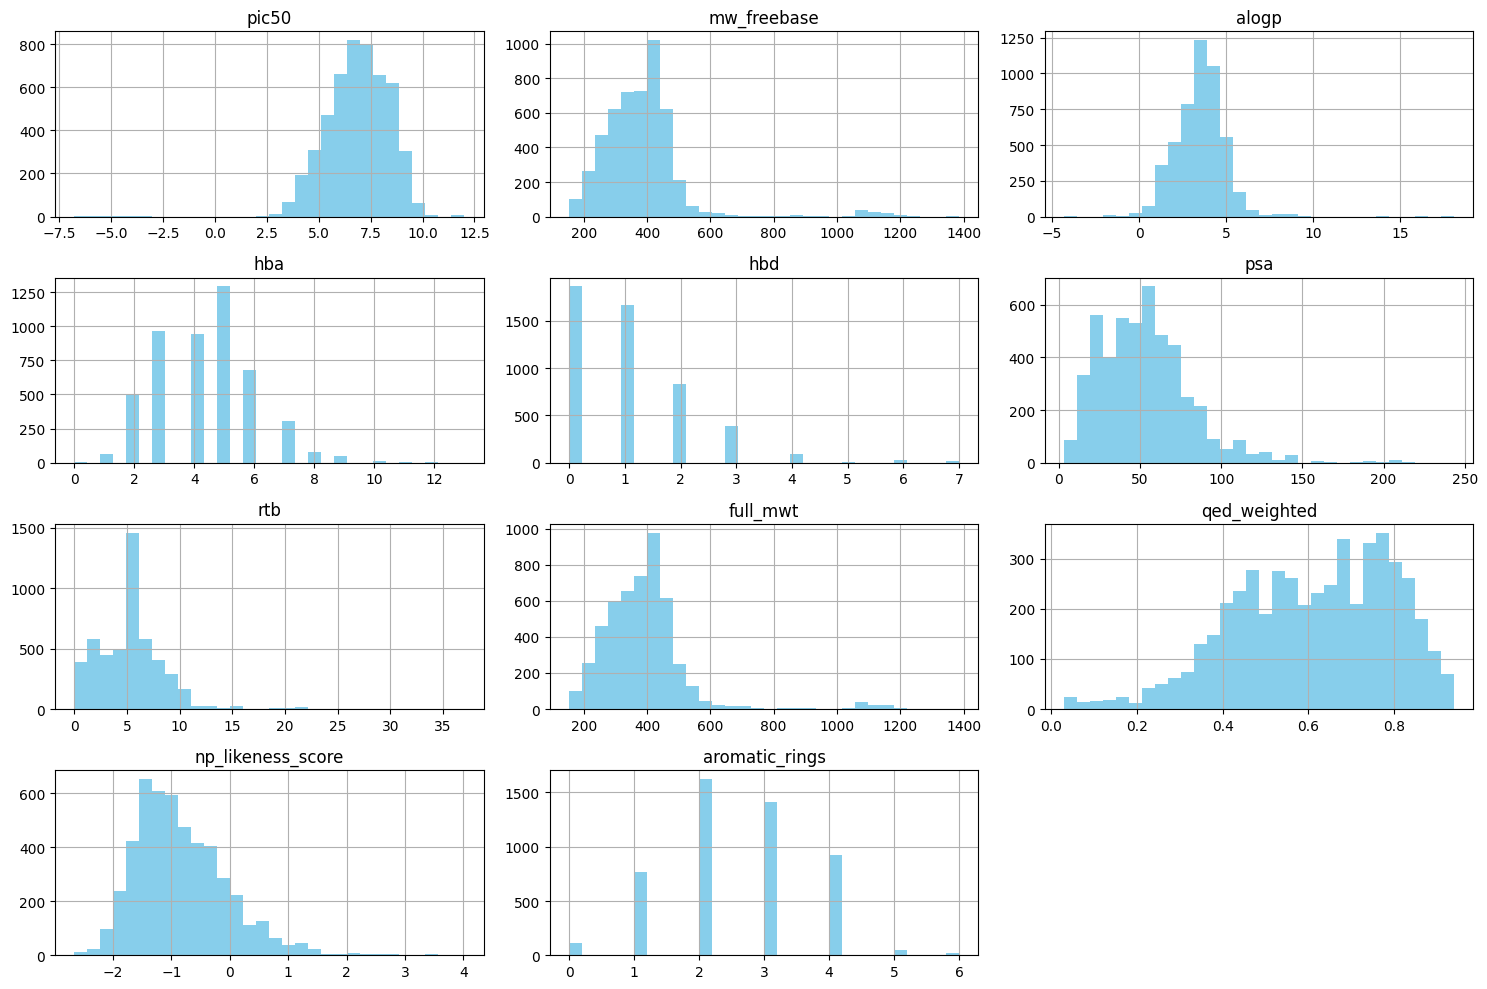

In [89]:

df_properites = df_properites.apply(pd.to_numeric, errors='coerce') 

# histogramy
df_properites.hist(bins=30, figsize=(15,10), color='skyblue')
plt.tight_layout()
plt.show()

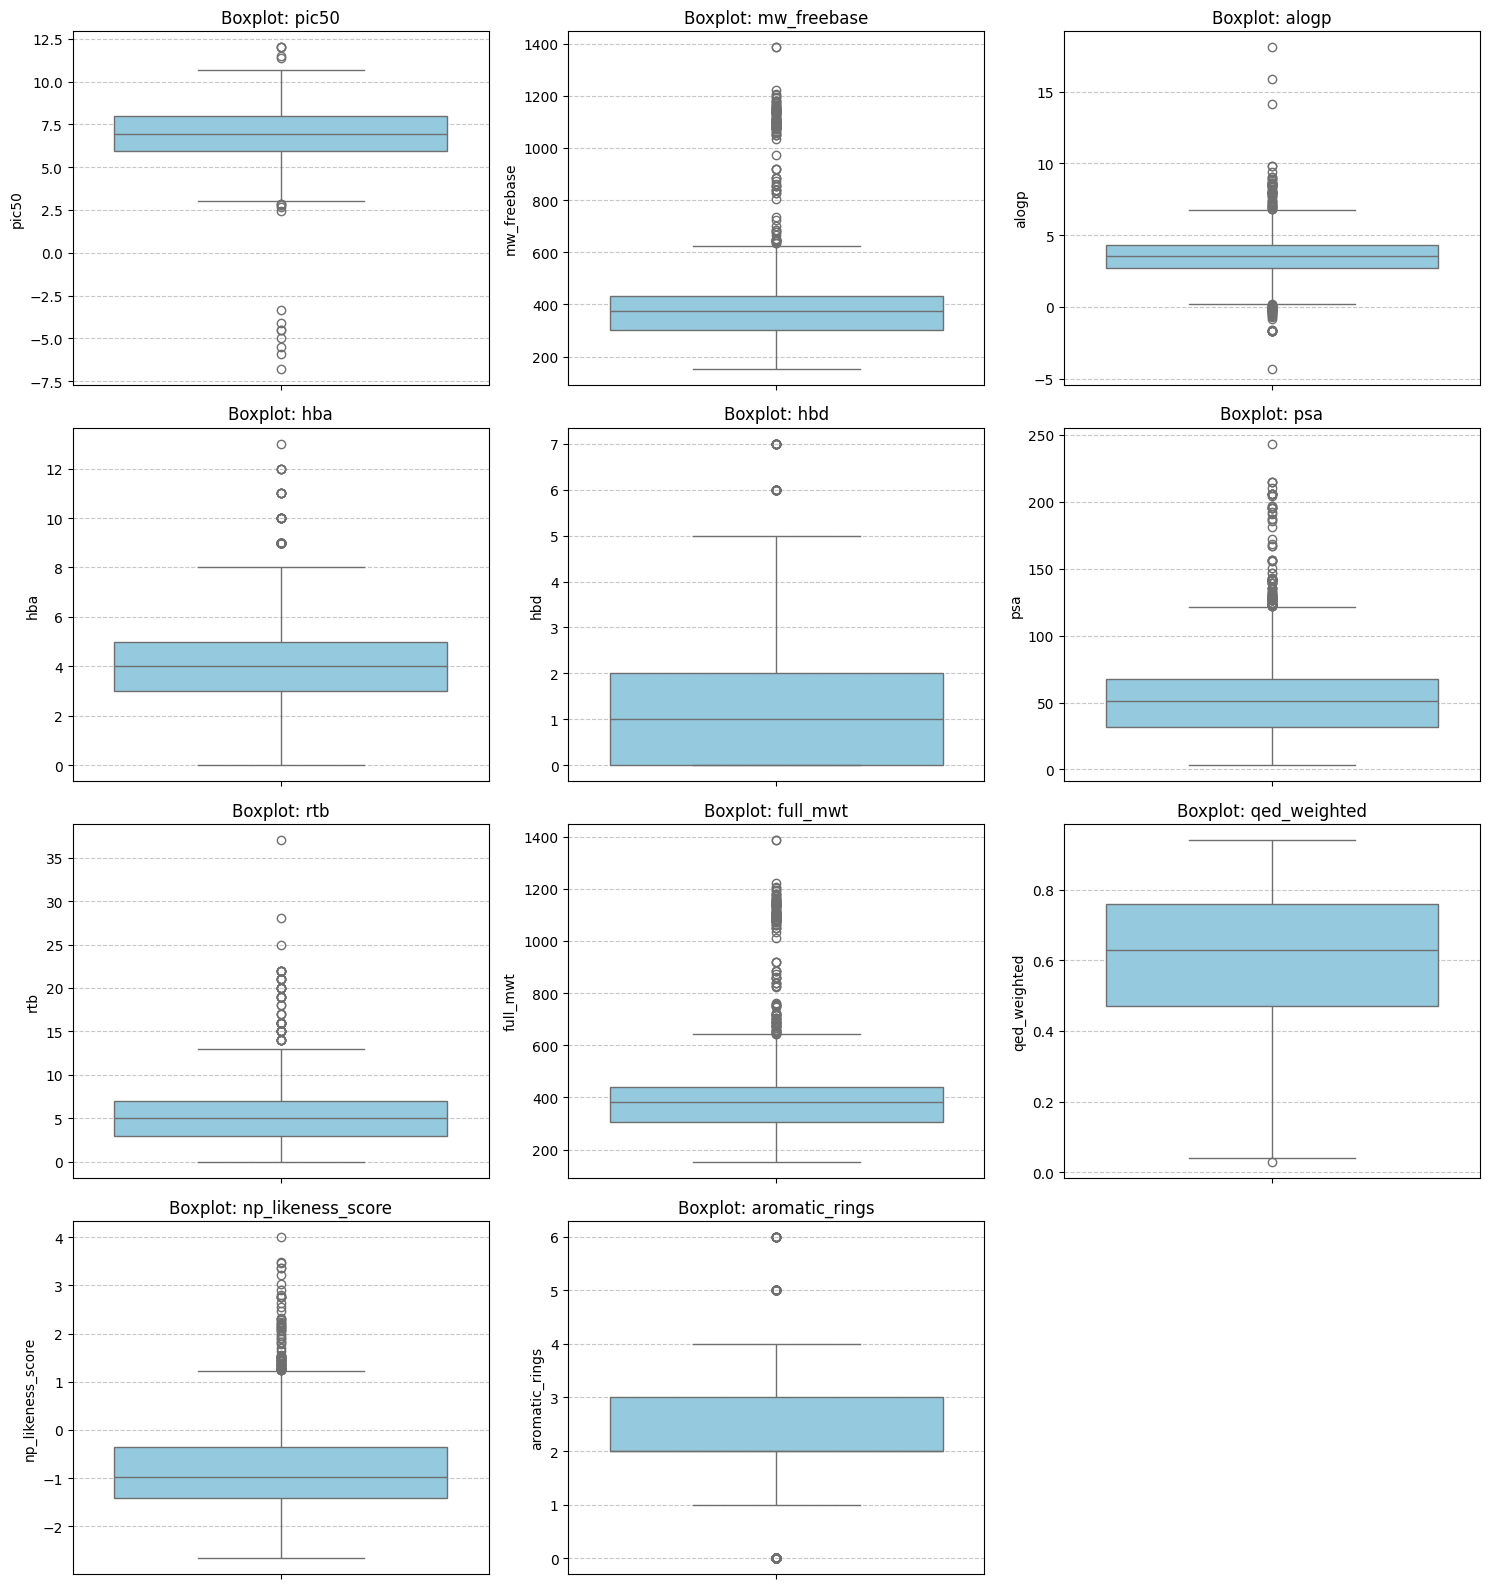

In [92]:
cols = df_properites.columns
n_cols = len(cols)

n_subcols = 3  # np. 3 boxploty w wierszu
n_rows = math.ceil(n_cols / n_subcols)

fig, axes = plt.subplots(n_rows, n_subcols, figsize=(5*n_subcols, 4*n_rows))
axes = axes.flatten()  # spłaszczamy do 1D, żeby łatwo iterować

for i, col in enumerate(cols):
    sns.boxplot(y=df_properites[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Trying to discover some correlations

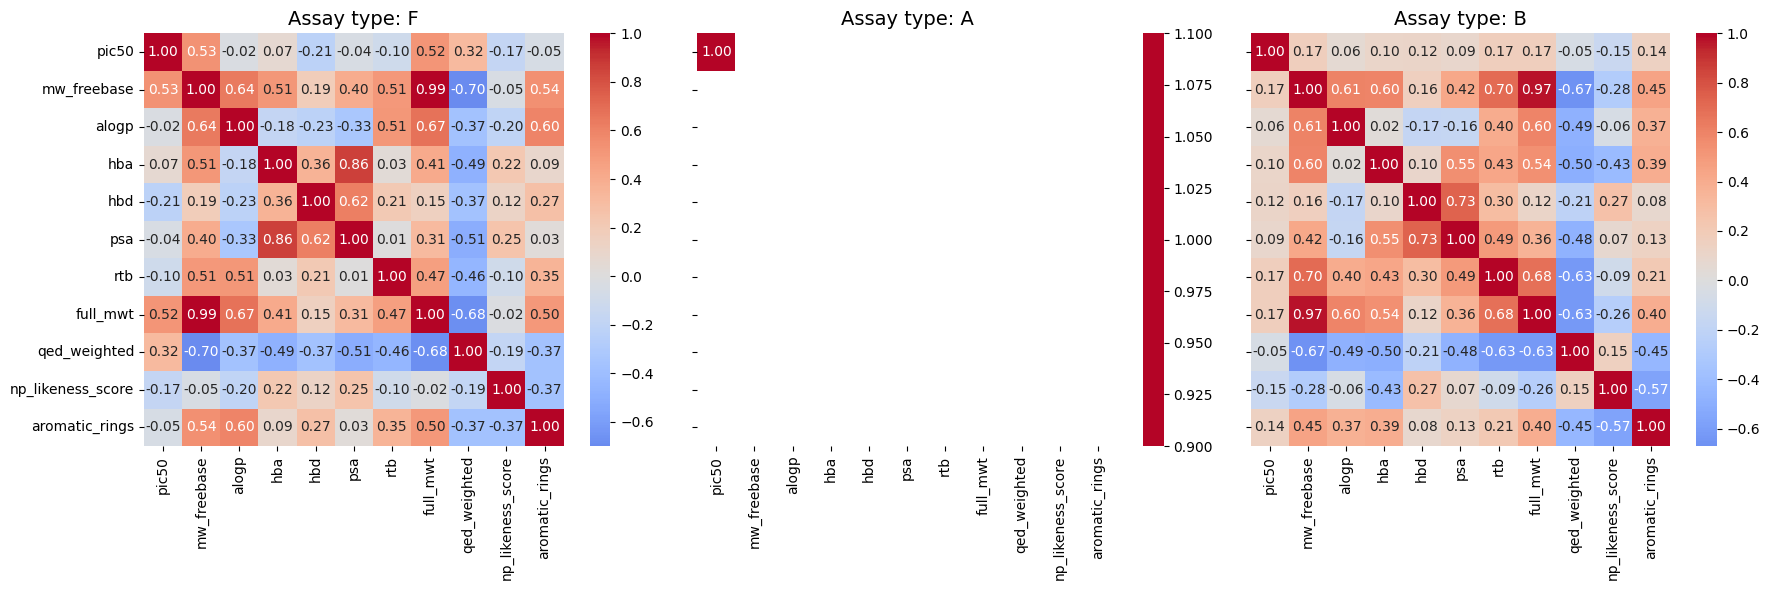

In [78]:

assay_types = df["assay_type"].unique()
fig, axes = plt.subplots(1, len(assay_types), figsize=(6*len(assay_types), 6), sharey=True)

for i, atype in enumerate(assay_types):
    df_sub = df[df["assay_type"] == atype]
    corr = df_sub[properites].corr()
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt=".2f", ax=axes[i])
    axes[i].set_title(f"Assay type: {atype}", fontsize=14)

plt.tight_layout()
plt.show()